# Active Lives 2019-20 — London EDA & Multi-Pillar Analysis (Wave 5)

Uses the shared `active_lives_utils` module. **All wave-specific settings verified** against this
wave's own `.sav` (validate_wave PASS, codebook compared, borough mapping GSS-proven).

> **2019-20 straddles the pandemic onset** — fieldwork ran Nov 2019 to Nov 2020, so the final
> months caught the first national lockdown. This is the wave most likely to show a genuine
> activity disruption. A rate below the ~62-64% band of other waves may be a real partial-lockdown
> effect (Sport England noted methodology caveats for this period), not an error.

### Verified differences from the 2022-23 baseline
- **Geography is `LA_2021`, but with SWAPPED codes** (8↔9 Barnet/Barking & Dagenham, 138↔139
  K&C/Islington) — the *same* convention as 2021-22, opposite to 2016-17/2022-23. Handled by
  deriving this wave's map from its own `.sav` (`build_london_map_from_sav`), GSS-proven.
- **`Eth7` code 3 = "South Asian"** here (like 2016-17), vs "Asian excl. Chinese" in 2022-23 —
  same code, different population. Harmonisation flag.
- **Indoor/outdoor & volunteering carry no `.sav` labels** — standard labels applied manually
  (data present: indoor/outdoor n=5,941, health n=15,813).
- Otherwise codings match baseline (health present and correctly coded, unlike 2016-17).

## 1. Imports & load

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import pyreadstat
from active_lives_utils import (decode, london_filter, weighted_share,
                                weighted_distribution, check_routing, validate_wave)

CSV = r"C:/Users/Lenovo/London-Sport-Forecasting-Patterns/data/processed/active_lives_london_y5_2019-20.csv"
SAV = r"C:/Users/Lenovo/London-Sport-Forecasting-Patterns/data/raw/active_lives_survey_nov_19-20_data_year_5_shared_20250103.sav"
df = pd.read_csv(CSV)
print("shape:", df.shape, "| year:", df["survey_year"].unique() if "survey_year" in df else "?")

shape: (16091, 589) | year: ['2019-20']


## 2. Build this wave's borough map from its own .sav (handles the swapped codes)

In [2]:
def build_london_map_from_sav(sav_path, la_col):
    _, meta = pyreadstat.read_sav(sav_path, metadataonly=True)
    labels = meta.variable_value_labels.get(la_col, {})
    m = {}
    for code, lbl in labels.items():
        s = str(lbl)
        if s.startswith("E09"):
            gss = s.split()[0]; m[int(code)] = (gss, s[len(gss):].strip())
    return m

def verify_borough_mapping(sav_path, la_col, london_map):
    _, meta = pyreadstat.read_sav(sav_path, metadataonly=True)
    labels = meta.variable_value_labels.get(la_col, {})
    mism = [f"code {c}: map {g} {n} vs .sav {labels.get(c)!r}"
            for c,(g,n) in london_map.items()
            if labels.get(c) is not None and g not in str(labels.get(c))]
    print("=== verify_borough_mapping ->", "PROVEN OK" if not mism else f"{len(mism)} MISMATCH", "===")
    for x in mism: print("  -", x)
    return mism

LA_COL = "LA_2021"
LONDON_MAP = build_london_map_from_sav(SAV, LA_COL)
print(f"{len(LONDON_MAP)} London codes derived from {LA_COL}")
verify_borough_mapping(SAV, LA_COL, LONDON_MAP)

33 London codes derived from LA_2021
=== verify_borough_mapping -> PROVEN OK ===


[]

## 3. Validate the wave

In [3]:
validate_wave(df, "2019-20", expected_active=0.62, tol=0.07)   # wider tol: possible pandemic effect
print("coverage (this wave's map):",
      round(df[LA_COL].map({k:v[0] for k,v in LONDON_MAP.items()}).notna().mean(), 3))

=== validate_wave: 2019-20 -> PASS ===
coverage (this wave's map): 1.0


## 4. Codebook & config (verified against this wave's .sav)

In [4]:
CODEBOOK = {
    "MEMS7GR_SPORTCOUNT_A01": {0: "Inactive", 1: "Fairly Active", 2: "Active"},
    "MEMS7GR_IN_SPORTCOUNT_A01":  {0: "Inactive", 1: "Fairly Active", 2: "Active"},
    "MEMS7GR_OUT_SPORTCOUNT_A01": {0: "Inactive", 1: "Fairly Active", 2: "Active"},
    "Gend3": {1: "Male", 2: "Female", 3: "Other"},
    # code 3 = South Asian in 2019-20 (like 2016-17; differs from 2022-23 'Asian excl. Chinese')
    "Eth7":  {1: "White British", 2: "White Other", 3: "South Asian",
              4: "Black", 5: "Chinese", 6: "Mixed", 7: "Other ethnic group"},
    "Disab3": {1: "Limiting disability", 2: "Non-limiting disability", 3: "No disability"},
    "Age9": {1: "14-15", 2: "16-24", 3: "25-34", 4: "35-44", 5: "45-54",
             6: "55-64", 7: "65-74", 8: "75-84", 9: "85+"},
    "NSSEC5": {1: "Higher social groups (NS-SEC 1-2)", 2: "Middle social groups (NS-SEC 3-5)",
               3: "Lower social groups (NS-SEC 6-8)", 4: "Students and other (NS-SEC 9)",
               5: "Aged <16 or 75+ (outside classification)"},
    "Educ6": {1: "Level 4 or above", 2: "Level 3 and equivalents", 3: "Level 2 and equivalents",
              4: "Level 1 and below", 5: "Another type of qualification", 6: "No qualifications"},
    "health": {1: "Very good", 2: "Good", 3: "Fair", 4: "Bad", 5: "Very bad"},
    "BMIG": {1: "Underweight", 2: "Healthy weight", 3: "Overweight", 4: "Obese", 5: "Morbidly obese"},
    "VolAny": {0: "Did not volunteer", 1: "Volunteered"},
}
VOL_ROLES = {
    "volint1_vol": "Raising funds", "volint2_vol": "Providing transport",
    "volint3_vol": "Coaching/instructing", "volint4_vol": "Refereeing/officiating",
    "volint5_vol": "Administrative/committee role", "volint6_vol": "Stewarding/marshalling",
    "volint7_vol": "Other help",
}
CONFIG = {
    "weight":"wt_final", "la_code":LA_COL,
    "activity_band":"MEMS7GR_SPORTCOUNT_A01",
    "activity_in":"MEMS7GR_IN_SPORTCOUNT_A01", "activity_out":"MEMS7GR_OUT_SPORTCOUNT_A01",
    "age":"Age9", "gender":"Gend3", "ethnicity":"Eth7", "disability":"Disab3",
    "nssec":"NSSEC5", "education":"Educ6", "bmi":"BMIG", "volunteer":"VolAny", "health":"health",
}

## 5. Decode & build the London frame

In [5]:
if "Age9" in df.columns:
    df = df[df["Age9"] != 1.0].copy()
CONFIG = {k:v for k,v in CONFIG.items() if (k=="weight" or v in df.columns)}
data = decode(df, CONFIG, CODEBOOK)
london = london_filter(data, la_col=LA_COL, la_map=LONDON_MAP)
print(f"London frame: {len(london):,} rows, {london['LA_name'].nunique()} boroughs (expect 32)")

London frame: 16,091 rows, 32 boroughs (expect 32)


## 6. Missingness & routing

In [6]:
concept_cols = [c for c in ["activity_band","activity_in","activity_out","age","gender",
    "ethnicity","disability","nssec","education","health","bmi","volunteer","weight"] if c in london.columns]
print((london[concept_cols].isna().mean()*100).round(1).sort_values(ascending=False).to_string())
role_cols=[c for c in london.columns if c.startswith("volint")]
if role_cols: check_routing(london,"volunteer","Volunteered",role_cols,"Volunteer -> role detail")
disty=[c for c in london.columns if c.startswith("disty")]
if disty: check_routing(london,"disability","Limiting disability",disty,"Limiting disability -> impairment")

activity_in      63.1
activity_out     63.1
education        27.8
bmi              17.0
disability        6.8
nssec             6.7
ethnicity         6.6
volunteer         2.8
health            1.7
age               1.0
gender            0.3
activity_band     0.0
weight            0.0
Volunteer -> role detail=='Volunteered' (n=2802): max dep-missing=0.000, all-blank=0 (0.0%)
Limiting disability -> impairment=='Limiting disability' (n=2128): max dep-missing=0.021, all-blank=44 (2.1%)


## 7. Pillar 1 — Participation

In [7]:
overall = weighted_share(london, [], "activity_band", "Active")
print(f"Overall London % Active (2019-20): {overall:.3f}")
print("  context -> 2015-16:0.635 | 2016-17:0.623 | 2021-22:0.643 | 2022-23:0.643")
print("  (2019-20 straddles first lockdown — a dip here may be real)")
for f in ["age","gender","ethnicity","disability","nssec","education","health","bmi"]:
    if f in london.columns:
        print(f"\n=== % Active by {f} ===")
        print(weighted_share(london,[f],"activity_band","Active").dropna(subset=[f]).to_string(index=False))

Overall London % Active (2019-20): 0.623
  context -> 2015-16:0.635 | 2016-17:0.623 | 2021-22:0.643 | 2022-23:0.643
  (2019-20 straddles first lockdown — a dip here may be real)

=== % Active by age ===
  age  weighted_share    n
16-24        0.659343 1348
25-34        0.708941 3235
35-44        0.623328 3190
45-54        0.619267 2672
55-64        0.601941 2490
65-74        0.584215 1958
75-84        0.421969  836
  85+        0.178455  199

=== % Active by gender ===
gender  weighted_share    n
Female        0.604966 8931
  Male        0.644965 7031
 Other        0.421154   79

=== % Active by ethnicity ===
         ethnicity  weighted_share    n
             Black        0.546184  970
           Chinese        0.653258  308
             Mixed        0.719269  484
Other ethnic group        0.556522  464
       South Asian        0.510603 2215
     White British        0.678702 8078
       White Other        0.668659 2509

=== % Active by disability ===
             disability  weight

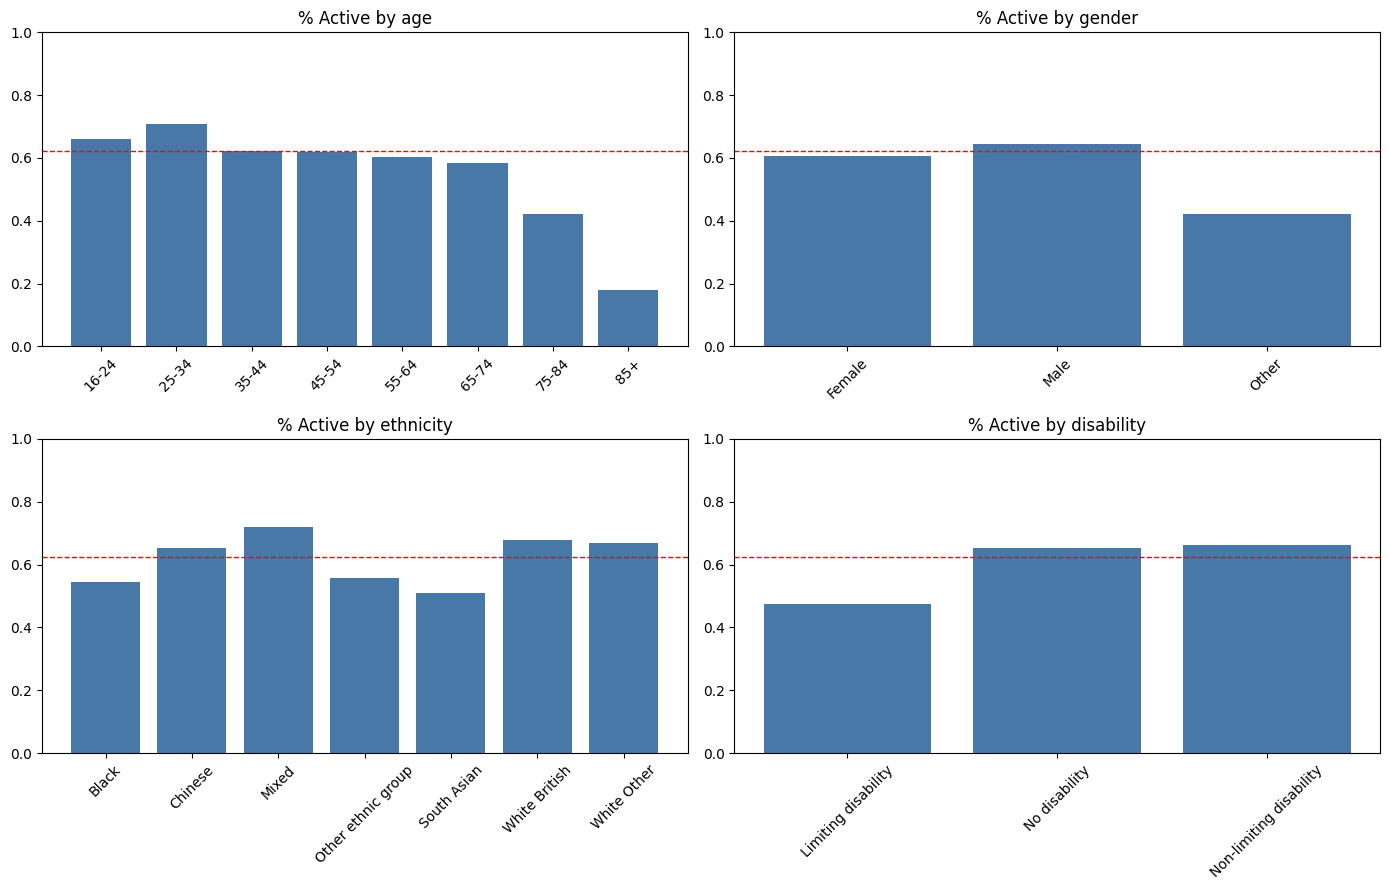

In [8]:
factors=[f for f in ["age","gender","ethnicity","disability"] if f in london.columns]
fig, axes = plt.subplots(2,2, figsize=(14,9))
for ax,f in zip(axes.ravel(), factors):
    r = weighted_share(london,[f],"activity_band","Active").dropna(subset=[f])
    ax.bar(r[f].astype(str), r["weighted_share"], color="#4878a8"); ax.set_ylim(0,1)
    ax.axhline(overall, color="red", ls="--", lw=1); ax.set_title(f"% Active by {f}")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

### Pillar 1 — by borough

               LA_name  weighted_share   n
                Newham        0.502321 508
                Bexley        0.516782 495
  Barking and Dagenham        0.518070 488
             Redbridge        0.521306 523
              Havering        0.524753 478
                Harrow        0.536887 499
              Hounslow        0.554358 503
                 Brent        0.560586 532
               Enfield        0.572290 493
            Hillingdon        0.581391 490
                Ealing        0.582168 507
               Croydon        0.585753 486
                Barnet        0.605478 493
                Merton        0.613945 520
         Tower Hamlets        0.616774 504
           Westminster        0.617431 476
        Waltham Forest        0.619574 505
                Sutton        0.626306 486
             Greenwich        0.633535 503
                Camden        0.642222 492
              Lewisham        0.665739 539
              Haringey        0.669900 502
  Kingston 

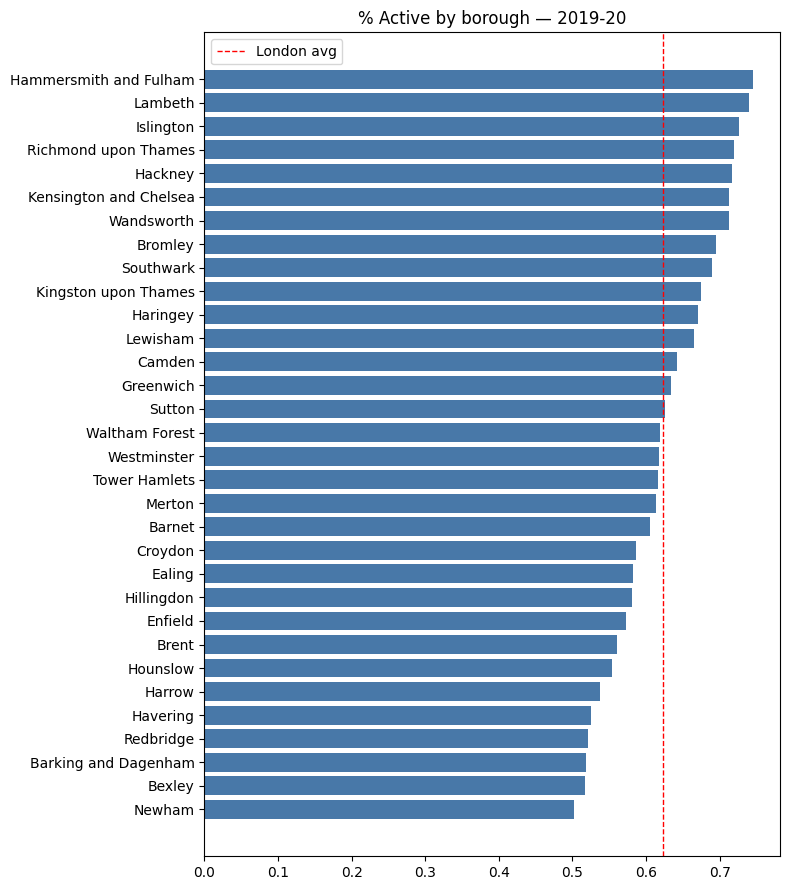

In [9]:
bor = weighted_share(london,["LA_name"],"activity_band","Active").sort_values("weighted_share")
print(bor.to_string(index=False))
fig, ax = plt.subplots(figsize=(8,9))
ax.barh(bor["LA_name"], bor["weighted_share"], color="#4878a8")
ax.axvline(overall, color="red", ls="--", lw=1, label="London avg")
ax.set_title("% Active by borough — 2019-20"); ax.legend(); plt.tight_layout(); plt.show()

## 8. Pillar 3 — Indoor vs Outdoor (manual labels; subgroup ~5,941)

In [10]:
io = london.dropna(subset=["activity_in","activity_out","weight"]).copy()
print(f"Indoor/outdoor base: {len(io):,} of {len(london):,}")
for place,col in [("Indoor","activity_in"),("Outdoor","activity_out")]:
    print(f"{place}: weighted % active = {weighted_share(io,[],col,'Active'):.3f}")

Indoor/outdoor base: 5,941 of 16,091
Indoor: weighted % active = 0.232
Outdoor: weighted % active = 0.528


## 9. Pillar 4 — Volunteering

In [11]:
print(f"Overall weighted % volunteered: {weighted_share(london,[],'volunteer','Volunteered'):.3f}")
print("  context -> 2016-17:0.229 | 2021-22:0.167 | 2022-23:0.183")
for f in ["age","gender","disability","nssec"]:
    if f in london.columns:
        print(f"\n=== % Volunteered by {f} ===")
        print(weighted_share(london,[f],"volunteer","Volunteered").dropna(subset=[f]).to_string(index=False))
vols = london[london["volunteer"]=="Volunteered"].dropna(subset=["weight"]).copy()
rs={}
for col,label in VOL_ROLES.items():
    if col in vols.columns:
        d=vols.dropna(subset=[col]); rs[label]=(d[col]*d["weight"]).sum()/d["weight"].sum()
if rs: print("\nRole mix:"); print(pd.Series(rs).sort_values(ascending=False).round(3).to_string())

Overall weighted % volunteered: 0.184
  context -> 2016-17:0.229 | 2021-22:0.167 | 2022-23:0.183

=== % Volunteered by age ===
  age  weighted_share    n
16-24        0.263201 1338
25-34        0.163591 3204
35-44        0.178774 3145
45-54        0.200557 2621
55-64        0.161091 2398
65-74        0.156655 1871
75-84        0.139846  758
  85+        0.124884  180

=== % Volunteered by gender ===
gender  weighted_share    n
Female        0.154769 8705
  Male        0.214282 6823
 Other        0.178318   79

=== % Volunteered by disability ===
             disability  weighted_share     n
    Limiting disability        0.143436  2026
          No disability        0.196933 10181
Non-limiting disability        0.169562  2406

=== % Volunteered by nssec ===
                            nssec  weighted_share    n
Higher social groups (NS-SEC 1-2)        0.205213 9154
 Lower social groups (NS-SEC 6-8)        0.129193 1347
Middle social groups (NS-SEC 3-5)        0.153591 2654
    Students

## 10. Pillar 2 — Regression (health included)

In [12]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
terms = ['C(age)','C(gender, Treatment(reference="Female"))',
         'C(disability, Treatment(reference="No disability"))',
         'C(ethnicity, Treatment(reference="White British"))']
need=["activity_band","age","gender","disability","ethnicity","weight"]
if "nssec" in london.columns: terms.append("C(nssec)"); need.append("nssec")
if "health" in london.columns: terms.append("C(health)"); need.append("health")
m = london.dropna(subset=need).copy(); m["active"]=(m["activity_band"]=="Active").astype(int)
print(f"Complete-case: {len(m):,} of {len(london):,} ({len(m)/len(london):.0%}) | health in model: {'health' in london.columns}")
model = smf.glm("active ~ "+" + ".join(terms), data=m, family=sm.families.Binomial(), freq_weights=m["weight"]).fit()
print(pd.DataFrame({"odds_ratio":np.exp(model.params),"p_value":model.pvalues,
    "ci_low":np.exp(model.conf_int()[0]),"ci_high":np.exp(model.conf_int()[1])}).round(3).to_string())

Complete-case: 13,176 of 16,091 (82%) | health in model: True
                                                                                odds_ratio  p_value  ci_low  ci_high
Intercept                                                                            1.653    0.000   1.339    2.040
C(age)[T.25-34]                                                                      0.888    0.047   0.789    0.998
C(age)[T.35-44]                                                                      0.640    0.000   0.568    0.721
C(age)[T.45-54]                                                                      0.673    0.000   0.595    0.762
C(age)[T.55-64]                                                                      0.619    0.000   0.544    0.705
C(age)[T.65-74]                                                                      0.454    0.000   0.394    0.523
C(gender, Treatment(reference="Female"))[T.Male]                                     1.124    0.000   1.061    1.192
C(

## 11. Save & five-wave comparison (computed live)

In [13]:
london.to_parquet("london_2019_20_clean.parquet")
print("saved", london.shape)

# Build the comparison live from each wave's parquet (no hard-coded values)
import os
waves = {"2015-16":"london_2015_16_clean.parquet","2016-17":"london_2016_17_clean.parquet",
         "2019-20":"london_2019_20_clean.parquet","2021-22":"london_2021_22_clean.parquet",
         "2022-23":"london_2022_23_clean.parquet"}
rows=[]
for w,p in waves.items():
    if os.path.exists(p):
        d=pd.read_parquet(p)
        rate=((d["activity_band"]=="Active")*d["weight"]).sum()/d["weight"].sum()
        rows.append({"wave":w,"pct_active":round(rate,4),"n":len(d)})
print(pd.DataFrame(rows).to_string(index=False))

saved (16091, 604)
   wave  pct_active     n
2015-16      0.6348 19887
2016-17      0.6228 19248
2019-20      0.6227 16091
2021-22      0.6427 16139
2022-23      0.6434 16515


## Findings — to complete after running
- Overall active 2019-20: ___ — **is there a pandemic dip** vs the stable ~62-64% of other waves?
  (This wave caught the first lockdown; a real dip would be the key finding.)
- Borough range: ___ to ___.
- Volunteering: ___% | Indoor/outdoor: ___ / ___.

### Coherence for synthesis (verified)
- Borough map derived from this wave's own .sav, GSS-proven. **Swapped codes** (8↔9, 138↔139),
  same convention as 2021-22. Join the panel on `gss`, never the integer code.
- Eth7 code 3 = South Asian (like 2016-17) — not directly comparable to 2022-23's 'Asian excl Chinese'.